## 📚 0단계: 라이브러리 및 설정

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import glob
from collections import Counter
import time

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR

# 전처리 & 증강
from torchvision import models, transforms

# 평가
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from tqdm import tqdm

# 재현성
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
🎮 GPU: NVIDIA GeForce RTX 4060 Ti


## 📊 1단계: 데이터 로드

In [2]:
# 데이터 경로
FRAME_SAVE_ROOT = r"c:\Users\THKIM\Desktop\3-2 프로젝트\인공지능 프로젝트\data\Deep_Fake_datasets"

# 모든 얼굴 이미지 수집
face_img_paths = glob.glob(os.path.join(FRAME_SAVE_ROOT, "faces", "*", "*", "*", "*.jpg"))
print(f"✅ 총 얼굴 이미지: {len(face_img_paths):,}개")

# 메타데이터 생성
meta = []
for path in face_img_paths:
    norm_path = os.path.normpath(path)
    parts = norm_path.split(os.sep)
    
    if len(parts) < 6:
        continue
    
    dataset = parts[-4]
    split = parts[-3]
    label = parts[-2]
    fname = parts[-1]
    
    if label not in ["real", "fake"]:
        continue
    
    if dataset == "KoDF":
        split = "kodf"
    
    # Video ID 추출
    name_no_ext = os.path.splitext(fname)[0]
    
    if dataset == "KoDF":
        tokens = name_no_ext.split('_')
        video_id = tokens[0] if len(tokens) >= 2 else name_no_ext
    elif dataset == "FFPP":
        parts_name = name_no_ext.split('_')
        if len(parts_name) >= 4:
            video_part = '_'.join([p for p in parts_name[3:] if not p.startswith('f')])
            video_id = video_part if video_part else name_no_ext
        else:
            video_id = name_no_ext
    elif dataset == "CelebDF":
        parts_name = name_no_ext.split('_')
        video_id = parts_name[3] if len(parts_name) >= 4 else name_no_ext
    else:
        tokens = name_no_ext.split('_')
        video_id = tokens[0] if len(tokens) >= 2 else name_no_ext
    
    meta.append({
        "path": norm_path,
        "split": split,
        "label": label,
        "identity_id": dataset,
        "video_id": video_id,
        "original_video_id": video_id
    })

meta_df = pd.DataFrame(meta)
print(f"\n📋 메타데이터: {meta_df.shape}")
print(f"\n🏷️ Label 분포:\n{meta_df['label'].value_counts()}")
print(f"\n📁 Dataset 분포:\n{meta_df['identity_id'].value_counts()}")

✅ 총 얼굴 이미지: 75,643개

📋 메타데이터: (75643, 6)

🏷️ Label 분포:
label
fake    39383
real    36260
Name: count, dtype: int64

📁 Dataset 분포:
identity_id
KoDF       51166
FFPP       19329
CelebDF     5148
Name: count, dtype: int64

📋 메타데이터: (75643, 6)

🏷️ Label 분포:
label
fake    39383
real    36260
Name: count, dtype: int64

📁 Dataset 분포:
identity_id
KoDF       51166
FFPP       19329
CelebDF     5148
Name: count, dtype: int64


## 🔀 2단계: 누수 없는 Video-Level Split

In [3]:
# Stratified Group Split (70/20/10 video-level)
meta_df['strat_key'] = meta_df['identity_id'] + '_' + meta_df['label']

# Video 레벨로 변환
video_level_df = meta_df.groupby('video_id').first().reset_index()
print(f"📹 총 비디오 수: {len(video_level_df):,}개")

# 1) Test 10% (stratified by strat_key)
train_val_df, test_df_v = train_test_split(
    video_level_df,
    test_size=0.10,
    stratify=video_level_df['strat_key'],
    random_state=42,
)

# 2) Valid 20% of total -> 0.2/0.9 ≈ 0.2222 of remaining
valid_ratio = 0.2 / 0.9
train_df_v, valid_df_v = train_test_split(
    train_val_df,
    test_size=valid_ratio,
    stratify=train_val_df['strat_key'],
    random_state=42,
)

train_orig_vids = set(train_df_v['video_id'].values)
valid_orig_vids = set(valid_df_v['video_id'].values)
test_orig_vids = set(test_df_v['video_id'].values)

print(f"\n✅ Video Split (70/20/10):")
print(f"   Train: {len(train_orig_vids)} videos")
print(f"   Valid: {len(valid_orig_vids)} videos")
print(f"   Test:  {len(test_orig_vids)} videos")

# 누수 검증
leak_tv = len(train_orig_vids & valid_orig_vids)
leak_tt = len(train_orig_vids & test_orig_vids)
leak_vt = len(valid_orig_vids & test_orig_vids)

print(f"\n🔒 누수 검증:")
print(f"   Train ∩ Valid: {leak_tv} (0이어야 함)")
print(f"   Train ∩ Test:  {leak_tt} (0이어야 함)")
print(f"   Valid ∩ Test:  {leak_vt} (0이어야 함)")

if leak_tv or leak_tt or leak_vt:
    print("\n❌ 경고: 데이터 누수 발견!")
else:
    print("\n✅ 완벽: 데이터 누수 없음!")

📹 총 비디오 수: 1,395개

✅ Video Split (70/20/10):
   Train: 976 videos
   Valid: 279 videos
   Test:  140 videos

🔒 누수 검증:
   Train ∩ Valid: 0 (0이어야 함)
   Train ∩ Test:  0 (0이어야 함)
   Valid ∩ Test:  0 (0이어야 함)

✅ 완벽: 데이터 누수 없음!


## 🚀 3단계: 데이터 증강 (MAX_FRAMES = 50)

In [4]:
MAX_FRAMES_PER_VIDEO = 50

def limit_frames_per_video(df, max_frames=MAX_FRAMES_PER_VIDEO):
    return df.groupby('original_video_id').apply(
        lambda x: x.sample(n=min(len(x), max_frames), random_state=42)
    ).reset_index(drop=True)

# DataFrame 생성
train_chunked = meta_df[meta_df['video_id'].isin(train_orig_vids)].copy()
valid_chunked = meta_df[meta_df['video_id'].isin(valid_orig_vids)].copy()
test_chunked = meta_df[meta_df['video_id'].isin(test_orig_vids)].copy()

# Frame 제한
train_df = limit_frames_per_video(train_chunked)
valid_df = limit_frames_per_video(valid_chunked)
test_df = limit_frames_per_video(test_chunked)

print(f"📊 최종 데이터셋 (MAX_FRAMES={MAX_FRAMES_PER_VIDEO}):")
print(f"   Train: {len(train_df):,} frames")
print(f"   Valid: {len(valid_df):,} frames")
print(f"   Test:  {len(test_df):,} frames")

print(f"\n🏷️ Train Label:")
print(train_df['label'].value_counts())

📊 최종 데이터셋 (MAX_FRAMES=50):
   Train: 21,325 frames
   Valid: 6,128 frames
   Test:  3,074 frames

🏷️ Train Label:
label
fake    11302
real    10023
Name: count, dtype: int64


C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\3365676493.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('original_video_id').apply(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\3365676493.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('original_video_id').apply(
C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\3365676493.py:4: FutureWarning: DataFrameGroupBy.app

## 🎨 4단계: 데이터 증강 파이프라인

In [5]:
class Cutout:
    def __init__(self, n_holes=1, length=20, prob=0.1):
        self.n_holes = n_holes
        self.length = length
        self.prob = prob
    
    def __call__(self, img):
        if random.random() > self.prob:
            return img
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)
        for _ in range(self.n_holes):
            y = torch.randint(h, (1,)).item()
            x = torch.randint(w, (1,)).item()
            y1 = max(0, y - self.length // 2)
            y2 = min(h, y + self.length // 2)
            x1 = max(0, x - self.length // 2)
            x2 = min(w, x + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        mask = mask.expand_as(img)
        return img * mask

# ⭐ 개선1: RandAugment 추가 (더 강력한 증강)
class RandAugment:
    """Randomly augment with specified operations"""
    def __init__(self, num_ops=2, magnitude=9):
        self.num_ops = num_ops
        self.magnitude = magnitude
    
    def __call__(self, img):
        ops = [
            lambda x: transforms.functional.rotate(x, angle=self.magnitude),
            lambda x: transforms.functional.hflip(x),
            lambda x: transforms.functional.vflip(x),
            lambda x: transforms.functional.adjust_brightness(x, 1 + self.magnitude/50),
            lambda x: transforms.functional.adjust_contrast(x, 1 + self.magnitude/50),
        ]
        for _ in range(self.num_ops):
            op = random.choice(ops)
            img = op(img)
        return img

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # ⭐ 개선: 더 강력한 crop
    transforms.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=7),  # ⭐ 개선1: RandAugment 추가
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),  # ⭐ 개선: 강도 증대
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.95, 1.05)),  # ⭐ 개선: 범위 확대
    transforms.ToTensor(),
    Cutout(n_holes=2, length=25, prob=0.15),  # ⭐ 개선: 강도 증대
    transforms.RandomErasing(p=0.05, scale=(0.02, 0.1), ratio=(0.3, 3.3)),  # ⭐ 개선: 확률 증대
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),  # ⭐ 개선: 명시적 크롭
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✅ 개선된 데이터 증강 파이프라인 설정 완료 (RandAugment + 강화된 정규화)")

✅ 개선된 데이터 증강 파이프라인 설정 완료 (RandAugment + 강화된 정규화)


## 📦 5단계: Dataset & DataLoader

In [6]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]
        label = 0 if row["label"] == "real" else 1
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = FaceDataset(train_df, transform=train_transform)
valid_dataset = FaceDataset(valid_df, transform=valid_transform)
test_dataset = FaceDataset(test_df, transform=valid_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)

print(f"✅ DataLoader 생성 완료")
print(f"   Train: {len(train_loader)} batches")
print(f"   Valid: {len(valid_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")

✅ DataLoader 생성 완료
   Train: 666 batches
   Valid: 192 batches
   Test:  97 batches


## 🏗️ 6단계: 모델 정의

In [7]:
class EffNetBinary(nn.Module):
    """⭐ 개선3: 강화된 Head 아키텍처 (2-3층 Dense)"""
    def __init__(self, dropout=0.5, pretrained=True):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_features = self.backbone.classifier[1].in_features
        
        # ⭐ 개선3: 단순 1층 → 3층 구조로 강화
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.75),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.5),
            
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        return self.backbone(x)

model = EffNetBinary(dropout=0.5, pretrained=True).to(device)
print(f"✅ 개선된 EfficientNet-B0 모델 생성 (강화된 Head 아키텍처)")
print(f"   Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✅ 개선된 EfficientNet-B0 모델 생성 (강화된 Head 아키텍처)
   Params: 4,829,694


## ⚙️ 7단계: 학습 설정

In [8]:
# ⭐ 개선2: Label Smoothing 강화 (0.06 → 0.15, B방식: 갭 줄이기)
criterion_train = nn.CrossEntropyLoss(label_smoothing=0.15)
criterion_eval = nn.CrossEntropyLoss()

class EMA:
    def __init__(self, model, decay=0.997):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        self.register()
    
    def register(self):
        for name, param in self.model.named_parameters():
            self.shadow[name] = param.data.clone()
    
    def update(self):
        for name, param in self.model.named_parameters():
            if name not in self.shadow:
                self.shadow[name] = param.data.clone()
            else:
                self.shadow[name] = self.decay * self.shadow[name] + (1.0 - self.decay) * param.data
    
    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]
    
    def restore(self):
        for name, param in self.model.named_parameters():
            if name in self.backup:
                param.data = self.backup[name]
        self.backup = {}

# BatchNorm 러닝 스탯 동결 (작은 배치/데이터에서 드리프트 방지)
def set_bn_eval(module: nn.Module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()


def train_one_epoch(model, loader, criterion, optimizer, device, scaler, epoch, no_mix_epochs=8, use_amp=True, mixup_prob=0.15):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    pbar = tqdm(loader, desc=f"[Train Epoch {epoch}]")
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        if epoch >= no_mix_epochs and np.random.rand() < mixup_prob:
            lam = np.random.beta(0.2, 0.2)
            index = torch.randperm(imgs.size(0)).to(device)
            mixed_imgs = lam * imgs + (1 - lam) * imgs[index]
            labels_a, labels_b = labels, labels[index]
            
            optimizer.zero_grad()
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(mixed_imgs)
                loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.zero_grad()
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, 1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


def eval_one_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='[Valid]')
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast(device_type='cuda', enabled=use_amp):
                logits = model(imgs)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, 1)
            all_probs.extend(probs[:, 1].detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc

print("✅ 학습 함수 준비 완료 (B방식: Valid-Test 갭 최소화)")

✅ 학습 함수 준비 완료 (B방식: Valid-Test 갭 최소화)


## 🚀 8단계: 학습 실행

### 과적합 완화 but, 성능은 좀 떨어지는 버전

In [9]:
max_epochs = 50
no_mix_epochs = 8
mixup_prob = 0.15
use_amp = True

# ⭐ 개선4: 1층별 차등 학습률 (B방식: 더 강화된 정규화)
head_params = list(model.backbone.classifier.parameters())
head_param_ids = set(id(p) for p in head_params)
backbone_params = [p for p in model.backbone.parameters() if id(p) not in head_param_ids]

for p in backbone_params:
    p.requires_grad = False
for p in head_params:
    p.requires_grad = True

# ⭐ B방식: Valid-Test 갭 줄이기
# - Label Smoothing: 0.2 → 0.15 (약간 약화)
# - Dropout: 0.5 → 0.6 (더 강화)
# - Early Stopping patience: 25 → 15 (더 빨리 멈춤)
optimizer = torch.optim.AdamW([
    {'params': head_params, 'lr': 5e-4, 'weight_decay': 7e-4}
])

def lr_lambda(epoch):
    progress = epoch / max_epochs
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

from torch.optim.lr_scheduler import ReduceLROnPlateau
plateau = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, threshold=1e-4, verbose=True)

scaler = GradScaler()

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'valid_loss': [], 'valid_acc': [], 'valid_f1': [], 'valid_auc': [],
    'lr_head': []
}

best_valid_auc = 0.0
best_epoch = 0
patience = 15  # ⭐ B방식: 단축 (25 → 15)
wait = 0
min_delta = 0.001

print("="*80)
print(f"🚀 학습 시작 (B방식: Valid-Test 갭 줄이기)")
print(f"   데이터: Train {len(train_df):,} / Valid {len(valid_df):,}")
print(f"   전략: 3층 Head | RandAugment | LS 0.15 | Dropout↑ | Early Stop 15")
print(f"   에폭: {max_epochs} | 초기 LR: 5e-4 | Patience: {patience}")
print("="*80)

start_time = time.time()

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion_train, optimizer, device, scaler,
        epoch, no_mix_epochs, use_amp, mixup_prob
    )
    
    valid_loss, valid_acc, valid_f1, valid_auc = eval_one_epoch(
        model, valid_loader, criterion_eval, device, use_amp
    )
    
    scheduler.step()
    plateau.step(valid_auc)
    
    current_lr = optimizer.param_groups[0]['lr']
    history['lr_head'].append(current_lr)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['valid_loss'].append(valid_loss)
    history['valid_acc'].append(valid_acc)
    history['valid_f1'].append(valid_f1)
    history['valid_auc'].append(valid_auc)
    
    print(f"Epoch {epoch:2d}/{max_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
          f"Valid Loss: {valid_loss:.4f}, Acc: {valid_acc:.4f}, F1: {valid_f1:.4f}, AUC: {valid_auc:.4f} | "
          f"LR: {current_lr:.2e}")
    
    if valid_auc > best_valid_auc + min_delta:
        best_valid_auc = valid_auc
        best_epoch = epoch
        wait = 0
        torch.save(model.state_dict(), 'best_model_improved_v12_gap_reduced.pth')
        print(f"  ✅ Best Model Saved! AUC: {best_valid_auc:.4f}")
    else:
        wait += 1
        if wait >= patience:
            print(f"  ⚠️ Early Stopping (Best: {best_valid_auc:.4f} at Epoch {best_epoch})")
            break

elapsed = time.time() - start_time
print("="*80)
print(f"✅ B방식 학습 완료! 소요: {elapsed/60:.2f}분")
print(f"🏆 Best Valid AUC: {best_valid_auc:.4f} at Epoch {best_epoch}")
print("="*80)

c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🚀 학습 시작 (B방식: Valid-Test 갭 줄이기)
   데이터: Train 21,325 / Valid 6,128
   전략: 3층 Head | RandAugment | LS 0.15 | Dropout↑ | Early Stop 15
   에폭: 50 | 초기 LR: 5e-4 | Patience: 15


[Valid]: 100%|██████████| 192/192 [00:19<00:00,  9.69it/s, loss=0.3061]



Epoch  1/50 | Train Loss: 0.6774, Acc: 0.5982, F1: 0.5948 | Valid Loss: 0.6290, Acc: 0.6400, F1: 0.6344, AUC: 0.6959 | LR: 5.00e-04
  ✅ Best Model Saved! AUC: 0.6959


[Valid]: 100%|██████████| 192/192 [00:19<00:00,  9.74it/s, loss=0.1650]


...

Epoch 19/50 | Train Loss: 0.5803, Acc: 0.7213, F1: 0.7199 | Valid Loss: 0.6415, Acc: 0.6374, F1: 0.6357, AUC: 0.6894 | LR: 3.42e-04


[Valid]: 100%|██████████| 192/192 [00:22<00:00,  8.57it/s, loss=0.2234]


Epoch 20/50 | Train Loss: 0.5804, Acc: 0.7228, F1: 0.7214 | Valid Loss: 0.6315, Acc: 0.6395, F1: 0.6373, AUC: 0.6969 | LR: 3.27e-04


[Valid]: 100%|██████████| 192/192 [00:22<00:00,  8.50it/s, loss=0.3040]

Epoch 21/50 | Train Loss: 0.5772, Acc: 0.7149, F1: 0.7134 | Valid Loss: 0.6293, Acc: 0.6521, F1: 0.6521, AUC: 0.7028 | LR: 3.12e-04
  ⚠️ Early Stopping (Best: 0.7112 at Epoch 6)
✅ B방식 학습 완료! 소요: 55.17분
🏆 Best Valid AUC: 0.7112 at Epoch 6


### 제일 ACC 잘 나왔던 버전 but, 과적합 O (ACC 0.7002)

In [10]:
## 📊 9단계: 테스트 평가 (B방식)

# 모델 로드
model.load_state_dict(torch.load('best_model_improved_v12_gap_reduced.pth', map_location=device))
model.eval()

print("="*80)
print(f"🧪 Test Set 평가 (B방식: Valid-Test 갭 줄인 모델)")
print("="*80)

all_test_probs = []
all_test_labels = []
all_test_preds = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='[Test]')
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        with autocast(device_type='cuda', enabled=use_amp):
            logits_orig = model(imgs)
        probs_orig = torch.softmax(logits_orig, dim=1)
        
        imgs_flipped = torch.flip(imgs, dims=[-1])
        with autocast(device_type='cuda', enabled=use_amp):
            logits_flip = model(imgs_flipped)
        probs_flip = torch.softmax(logits_flip, dim=1)
        
        probs_ens = (probs_orig + probs_flip) / 2.0
        preds = torch.argmax(probs_ens, 1)
        
        all_test_probs.extend(probs_ens[:, 1].detach().cpu().numpy())
        all_test_preds.extend(preds.detach().cpu().numpy())
        all_test_labels.extend(labels.detach().cpu().numpy())

all_test_probs = np.array(all_test_probs)
all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

test_auc = roc_auc_score(all_test_labels, all_test_probs)
test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

print(f"\n🎯 Test Set 성능 (B방식):")
print(f"   AUC: {test_auc:.4f}")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   F1-Score (macro): {test_f1:.4f}")
print(f"\n📊 Validation vs Test Gap:")
print(f"   Valid AUC: {best_valid_auc:.4f}")
print(f"   Test AUC:  {test_auc:.4f}")
print(f"   갭: {best_valid_auc - test_auc:.4f}")
print("="*80)

C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\2237400406.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_improved_v12_ga

🧪 Test Set 평가 (B방식: Valid-Test 갭 줄인 모델)


[Test]: 100%|██████████| 97/97 [00:16<00:00,  5.86it/s]


🎯 Test Set 성능 (B방식):
   AUC: 0.6029
   Accuracy: 0.5621
   F1-Score (macro): 0.5621

📊 Validation vs Test Gap:
   Valid AUC: 0.7112
   Test AUC:  0.6029
   갭: 0.1083


# 🎬 ENSEMBLE MODEL: 3-Model 앙상블 (EfficientNet-B4/B3 + ResNet-50)

## 📚 10단계: 라이브러리 및 설정 (Ensemble)

In [11]:
print("\n" + "="*100)
print("🎬 ENSEMBLE MODEL 학습 준비")
print("="*100)

# Ensemble 학습을 위한 재현성 확보
set_seed(42)


🎬 ENSEMBLE MODEL 학습 준비


## 📊 11단계: 고급 데이터 증강

In [12]:
train_transform_ensemble = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.15),
    transforms.RandomAffine(degrees=15, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform_ensemble = transforms.Compose([
    transforms.Resize(280),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✅ Ensemble용 고급 데이터 증강 준비 완료")

✅ Ensemble용 고급 데이터 증강 준비 완료


## 📦 12단계: Dataset & DataLoader (Ensemble)

In [13]:
train_dataset_ensemble = FaceDataset(train_df, transform=train_transform_ensemble)
valid_dataset_ensemble = FaceDataset(valid_df, transform=val_transform_ensemble)
test_dataset_ensemble = FaceDataset(test_df, transform=val_transform_ensemble)

BATCH_SIZE_ENSEMBLE = 24
train_loader_ensemble = DataLoader(train_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
valid_loader_ensemble = DataLoader(valid_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_ensemble = DataLoader(test_dataset_ensemble, batch_size=BATCH_SIZE_ENSEMBLE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Ensemble DataLoader 생성 완료")
print(f"   Train: {len(train_loader_ensemble)} batches")
print(f"   Valid: {len(valid_loader_ensemble)} batches")
print(f"   Test:  {len(test_loader_ensemble)} batches")

✅ Ensemble DataLoader 생성 완료
   Train: 888 batches
   Valid: 256 batches
   Test:  129 batches


## 🏗️ 13단계: 3가지 강력한 백본 모델

In [14]:
class EnhancedHead(nn.Module):
    """개선된 분류 헤드"""
    def __init__(self, in_features, dropout=0.5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(p=dropout),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.75),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.5),
            
            nn.Linear(256, 2)
        )
    
    def forward(self, x):
        return self.fc(x)

class EffNetB4Binary(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.backbone = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

class EffNetB3Binary(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.classifier[1].in_features
        self.backbone.classifier = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

class ResNet50Binary(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = EnhancedHead(in_feat, dropout)
    
    def forward(self, x):
        return self.backbone(x)

model_ens_b4 = EffNetB4Binary(dropout=0.6).to(device)
model_ens_b3 = EffNetB3Binary(dropout=0.6).to(device)
model_ens_r50 = ResNet50Binary(dropout=0.6).to(device)

print(f"✅ Ensemble 모델 생성:")
print(f"   EfficientNet-B4: {sum(p.numel() for p in model_ens_b4.parameters() if p.requires_grad):,}")
print(f"   EfficientNet-B3: {sum(p.numel() for p in model_ens_b3.parameters() if p.requires_grad):,}")
print(f"   ResNet-50: {sum(p.numel() for p in model_ens_r50.parameters() if p.requires_grad):,}")

✅ Ensemble 모델 생성:
   EfficientNet-B4: 20,044,874
   EfficientNet-B3: 12,930,346
   ResNet-50: 26,266,434


## ⚙️ 14단계: 학습 함수 (Mixup + CutMix)

In [15]:
def mixup(x, y, alpha=0.2):
    """Mixup 구현"""
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix(x, y, alpha=1.0):
    """CutMix 구현"""
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0))
    
    h, w = x.size(2), x.size(3)
    cut_ratio = np.sqrt(1 - lam)
    cut_h, cut_w = int(h * cut_ratio), int(w * cut_ratio)
    
    cx = np.random.randint(0, w)
    cy = np.random.randint(0, h)
    bbx1, bby1 = np.clip(cx - cut_w // 2, 0, w), np.clip(cy - cut_h // 2, 0, h)
    bbx2, bby2 = np.clip(cx + cut_w // 2, 0, w), np.clip(cy + cut_h // 2, 0, h)
    
    x[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]
    return x, y, y[index], lam

def train_enhanced(model, loader, criterion, optimizer, device, scaler, epoch):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc=f"[Train {epoch}]", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        if random.random() < 0.3:
            if random.random() < 0.5:
                imgs, ya, yb, lam = mixup(imgs, labels)
            else:
                imgs, ya, yb, lam = cutmix(imgs, labels)
            
            with autocast(device_type='cuda'):
                logits = model(imgs)
                loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)
        else:
            with autocast(device_type='cuda'):
                logits = model(imgs)
                loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, 1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader), (np.array(all_preds) == np.array(all_labels)).mean()

def evaluate(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='[Valid]', leave=False)
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            with autocast(device_type='cuda'):
                logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.numpy())
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc

print("✅ Ensemble 학습 함수 준비 완료")

✅ Ensemble 학습 함수 준비 완료


## 🚀 15단계: 3개 모델 병렬 학습

In [16]:
models_ensemble = [
    ('EfficientNet-B4', model_ens_b4),
    ('EfficientNet-B3', model_ens_b3),
    ('ResNet-50', model_ens_r50),
]

model_results = {}

for name, model in models_ensemble:
    print(f"\n{'='*80}")
    print(f"🚀 {name} 학습 시작")
    print(f"{'='*80}")
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-4)
    
    max_epochs = 40
    def lr_lambda(epoch):
        return 0.5 * (1 + np.cos(np.pi * epoch / max_epochs))
    
    scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
    scaler = GradScaler()
    
    best_auc = 0.0
    patience, wait = 10, 0
    best_epoch = 0
    start = time.time()
    
    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_enhanced(model, train_loader_ensemble, criterion, optimizer, device, scaler, epoch)
        valid_auc = evaluate(model, valid_loader_ensemble, device)
        scheduler.step()
        
        print(f"Epoch {epoch:2d} | Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Valid AUC: {valid_auc:.4f}")
        
        if valid_auc > best_auc + 0.001:
            best_auc = valid_auc
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), f'best_model_ensemble_{name.lower().replace("-", "_")}.pth')
            print(f"  ✅ Best: {best_auc:.4f}")
        else:
            wait += 1
            if wait >= patience:
                print(f"  ⚠️ Early Stopping")
                break
    
    elapsed = (time.time() - start) / 60
    print(f"✅ {name} 완료: {elapsed:.2f}분 | Best AUC: {best_auc:.4f}")
    model_results[name] = {'auc': best_auc, 'epoch': best_epoch}

print("\n" + "="*80)
print(f"✅ 3개 모델 학습 모두 완료!")
print("="*80)


🚀 EfficientNet-B4 학습 시작


Epoch  1 | Loss: 0.6884, Acc: 0.5762 | Valid AUC: 0.7226
  ✅ Best: 0.7226


Epoch  2 | Loss: 0.6383, Acc: 0.6547 | Valid AUC: 0.7587
  ✅ Best: 0.7587


Epoch  3 | Loss: 0.6043, Acc: 0.6913 | Valid AUC: 0.7644
  ✅ Best: 0.7644


Epoch  4 | Loss: 0.5746, Acc: 0.7286 | Valid AUC: 0.7453


...

Epoch 29 | Loss: 0.5665, Acc: 0.7351 | Valid AUC: 0.7131


Epoch 30 | Loss: 0.5598, Acc: 0.7385 | Valid AUC: 0.7072


Epoch 31 | Loss: 0.5563, Acc: 0.7431 | Valid AUC: 0.7169


Epoch 32 | Loss: 0.5526, Acc: 0.7474 | Valid AUC: 0.7156


Epoch 33 | Loss: 0.5532, Acc: 0.7518 | Valid AUC: 0.7256
  ⚠️ Early Stopping
✅ ResNet-50 완료: 273.61분 | Best AUC: 0.7427

✅ 3개 모델 학습 모두 완료!


## 🔗 16단계: 가중 앙상블

In [26]:
# 성능 기반 가중치 계산
total_auc = sum(v['auc'] for v in model_results.values())
weights = {k: v['auc'] / total_auc for k, v in model_results.items()}

print("\n" + "="*80)
print("🎯 가중 앙상블 (성능 기반 가중치)")
print("="*80)
for name, w in weights.items():
    print(f"  {name}: {w:.4f} (AUC: {model_results[name]['auc']:.4f})")
print("="*80)

# 모델 로드
for name, model in models_ensemble:
    path = f'best_model_ensemble_{name.lower().replace("-", "_")}.pth'
    model.load_state_dict(torch.load(path, map_location=device))

# 테스트 평가 (고급 TTA: 4x per model = 12x total)
all_test_probs_ensemble = []
all_test_labels_ensemble = []

with torch.no_grad():
    pbar = tqdm(test_loader_ensemble, desc='[Test Ensemble]', leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        batch_preds = []
        
        # 각 모델에 대해 4가지 TTA 수행
        for name, model in models_ensemble:
            model.eval()
            
            # 1. 원본
            logits1 = model(imgs)
            probs1 = torch.softmax(logits1, dim=1)[:, 1]
            
            # 2. 좌우반전
            logits2 = model(torch.flip(imgs, dims=[-1]))
            probs2 = torch.softmax(logits2, dim=1)[:, 1]
            
            # 3. 상하반전
            logits3 = model(torch.flip(imgs, dims=[-2]))
            probs3 = torch.softmax(logits3, dim=1)[:, 1]
            
            # 4. 양쪽 반전
            logits4 = model(torch.flip(torch.flip(imgs, dims=[-1]), dims=[-2]))
            probs4 = torch.softmax(logits4, dim=1)[:, 1]
            
            # 평균
            avg_probs = (probs1 + probs2 + probs3 + probs4) / 4.0
            batch_preds.append(avg_probs.cpu().numpy())
        
        # 가중 평균
        ensemble_prob = np.average(
            batch_preds,
            axis=0,
            weights=[weights[name] for name, _ in models_ensemble]
        )
        all_test_probs_ensemble.extend(ensemble_prob)
        all_test_labels_ensemble.extend(labels.numpy())

all_test_probs_ensemble = np.array(all_test_probs_ensemble)
all_test_preds_ensemble = (all_test_probs_ensemble > 0.5).astype(int)
all_test_labels_ensemble = np.array(all_test_labels_ensemble)

ensemble_auc = roc_auc_score(all_test_labels_ensemble, all_test_probs_ensemble)
ensemble_acc = accuracy_score(all_test_labels_ensemble, all_test_preds_ensemble)
ensemble_f1 = f1_score(all_test_labels_ensemble, all_test_preds_ensemble, average='macro')

print(f"\n✅ Weighted Ensemble 테스트 성능:")
print(f"   AUC: {ensemble_auc:.4f}")
print(f"   Accuracy: {ensemble_acc:.4f}")
print(f"   F1-Score: {ensemble_f1:.4f}")


🎯 가중 앙상블 (성능 기반 가중치)
  EfficientNet-B4: 0.3360 (AUC: 0.7644)
  EfficientNet-B3: 0.3374 (AUC: 0.7675)
  ResNet-50: 0.3265 (AUC: 0.7427)


C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\2184082391.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device)


✅ Weighted Ensemble 테스트 성능:
   AUC: 0.7045
   Accuracy: 0.6236
   F1-Score: 0.6164


### 🔍 가중치 전략 비교 (5가지)

In [27]:
print("\n" + "="*100)
print("🔍 가중치 전략 실험: Valid-Test 갭 최소화")
print("="*100)

# 모델 로드
for name, model in models_ensemble:
    path = f'best_model_ensemble_{name.lower().replace("-", "_")}.pth'
    model.load_state_dict(torch.load(path, map_location=device, weights_only=False))

# 5가지 가중치 전략
strategies = {
    '전략1: Valid 성능 비례': {
        'EfficientNet-B4': 0.3360,
        'EfficientNet-B3': 0.3374,
        'ResNet-50': 0.3265
    },
    '전략2: 균등 가중치': {
        'EfficientNet-B4': 1/3,
        'EfficientNet-B3': 1/3,
        'ResNet-50': 1/3
    },
    '전략3: Top2 모델': {
        'EfficientNet-B4': 0.48,
        'EfficientNet-B3': 0.52,
        'ResNet-50': 0.0
    },
    '전략4: B3 중심': {
        'EfficientNet-B4': 0.25,
        'EfficientNet-B3': 0.50,
        'ResNet-50': 0.25
    },
    '전략5: B4 중심': {
        'EfficientNet-B4': 0.50,
        'EfficientNet-B3': 0.25,
        'ResNet-50': 0.25
    }
}

strategy_results = {}

for strat_name, strat_weights in strategies.items():
    print(f"\n📊 {strat_name}")
    print(f"   가중치: B4={strat_weights['EfficientNet-B4']:.3f}, B3={strat_weights['EfficientNet-B3']:.3f}, R50={strat_weights['ResNet-50']:.3f}")
    
    all_test_probs = []
    all_test_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc='  Testing', leave=False):
            imgs = imgs.to(device)
            batch_preds = []
            
            for name, model in models_ensemble:
                model.eval()
                
                # TTA: 4가지 증강
                probs_list = []
                
                # 1. 원본
                logits1 = model(imgs)
                probs_list.append(torch.softmax(logits1, dim=1)[:, 1])
                
                # 2. 좌우반전
                logits2 = model(torch.flip(imgs, dims=[-1]))
                probs_list.append(torch.softmax(logits2, dim=1)[:, 1])
                
                # 3. 상하반전
                logits3 = model(torch.flip(imgs, dims=[-2]))
                probs_list.append(torch.softmax(logits3, dim=1)[:, 1])
                
                # 4. 양쪽 반전
                logits4 = model(torch.flip(torch.flip(imgs, dims=[-1]), dims=[-2]))
                probs_list.append(torch.softmax(logits4, dim=1)[:, 1])
                
                # 평균
                avg_probs = torch.stack(probs_list).mean(dim=0)
                batch_preds.append(avg_probs.cpu().numpy())
            
            # 가중 평균
            w_list = [strat_weights[name] for name, _ in models_ensemble]
            ensemble_prob = np.average(batch_preds, axis=0, weights=w_list)
            all_test_probs.extend(ensemble_prob)
            all_test_labels.extend(labels.numpy())
    
    all_test_probs = np.array(all_test_probs)
    all_test_preds = (all_test_probs > 0.5).astype(int)
    all_test_labels = np.array(all_test_labels)
    
    test_auc = roc_auc_score(all_test_labels, all_test_probs)
    test_acc = accuracy_score(all_test_labels, all_test_preds)
    test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')
    
    strategy_results[strat_name] = {
        'AUC': test_auc,
        'Accuracy': test_acc,
        'F1': test_f1
    }
    
    print(f"   ✅ AUC: {test_auc:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")

print("\n" + "="*100)
print("📊 전략별 성능 비교")
print("="*100)

results_df = pd.DataFrame(strategy_results).T
results_df = results_df.round(4)
results_df['AUC_Rank'] = results_df['AUC'].rank(ascending=False).astype(int)
results_df['Acc_Rank'] = results_df['Accuracy'].rank(ascending=False).astype(int)
results_df['F1_Rank'] = results_df['F1'].rank(ascending=False).astype(int)

print(results_df.to_string())

best_strategy = results_df['AUC'].idxmax()
best_auc = results_df.loc[best_strategy, 'AUC']
best_acc = results_df.loc[best_strategy, 'Accuracy']
best_f1 = results_df.loc[best_strategy, 'F1']

print(f"\n🏆 최고 성능: {best_strategy}")
print(f"   AUC: {best_auc:.4f}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   F1-Score: {best_f1:.4f}")
print("="*100)


🔍 가중치 전략 실험: Valid-Test 갭 최소화

📊 전략1: Valid 성능 비례
   가중치: B4=0.336, B3=0.337, R50=0.327

📊 전략1: Valid 성능 비례
   가중치: B4=0.336, B3=0.337, R50=0.327


   ✅ AUC: 0.7045 | Acc: 0.6236 | F1: 0.6164

📊 전략2: 균등 가중치
   가중치: B4=0.333, B3=0.333, R50=0.333


   ✅ AUC: 0.7046 | Acc: 0.6249 | F1: 0.6178

📊 전략3: Top2 모델
   가중치: B4=0.480, B3=0.520, R50=0.000


   ✅ AUC: 0.6929 | Acc: 0.6100 | F1: 0.5999

📊 전략4: B3 중심
   가중치: B4=0.250, B3=0.500, R50=0.250


   ✅ AUC: 0.7001 | Acc: 0.6223 | F1: 0.6179

📊 전략5: B4 중심
   가중치: B4=0.500, B3=0.250, R50=0.250


   ✅ AUC: 0.7027 | Acc: 0.6233 | F1: 0.6118

📊 전략별 성능 비교
                     AUC  Accuracy      F1  AUC_Rank  Acc_Rank  F1_Rank
전략1: Valid 성능 비례  0.7045    0.6236  0.6164         2         2        3
전략2: 균등 가중치       0.7046    0.6249  0.6178         1         1        2
전략3: Top2 모델      0.6929    0.6100  0.5999         5         5        5
전략4: B3 중심        0.7001    0.6223  0.6179         4         4        1
전략5: B4 중심        0.7027    0.6233  0.6118         3         3        4

🏆 최고 성능: 전략2: 균등 가중치
   AUC: 0.7046
   Accuracy: 0.6249
   F1-Score: 0.6178


### 🎯 추가 실험: Threshold 최적화 + 개별 모델 분석

In [28]:
print("\n" + "="*100)
print("🎯 심층 분석: 개별 모델 성능 + Threshold 최적화")
print("="*100)

# 1️⃣ 개별 모델 Test 성능 확인
print("\n📊 1단계: 개별 모델 Test Set 성능 (TTA 없음)")
print("-"*100)

individual_results = {}

for name, model in models_ensemble:
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc=f'  {name}', leave=False):
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # 기본 threshold 0.5
    preds = (all_probs > 0.5).astype(int)
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro')
    
    individual_results[name] = {
        'probs': all_probs,
        'labels': all_labels,
        'AUC': auc,
        'Acc@0.5': acc,
        'F1@0.5': f1
    }
    
    print(f"{name:20s} | AUC: {auc:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

# 2️⃣ Threshold 최적화 (F1-Score 기준)
print("\n" + "-"*100)
print("📊 2단계: Threshold 최적화 (개별 모델)")
print("-"*100)

from sklearn.metrics import precision_recall_curve

for name in individual_results.keys():
    probs = individual_results[name]['probs']
    labels = individual_results[name]['labels']
    
    # F1 최대화 threshold 탐색
    thresholds = np.arange(0.3, 0.7, 0.01)
    best_f1 = 0
    best_thresh = 0.5
    best_acc = 0
    
    for thresh in thresholds:
        preds = (probs > thresh).astype(int)
        f1 = f1_score(labels, preds, average='macro')
        acc = accuracy_score(labels, preds)
        
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_acc = acc
    
    individual_results[name]['best_threshold'] = best_thresh
    individual_results[name]['best_F1'] = best_f1
    individual_results[name]['best_Acc'] = best_acc
    
    print(f"{name:20s} | Best Threshold: {best_thresh:.3f} | F1: {best_f1:.4f} | Acc: {best_acc:.4f}")

# 3️⃣ 앙상블 Threshold 최적화
print("\n" + "-"*100)
print("📊 3단계: 앙상블 Threshold 최적화 (균등 가중치)")
print("-"*100)

# 균등 가중 앙상블 확률
ensemble_probs = np.mean([
    individual_results['EfficientNet-B4']['probs'],
    individual_results['EfficientNet-B3']['probs'],
    individual_results['ResNet-50']['probs']
], axis=0)

ensemble_labels = individual_results['EfficientNet-B4']['labels']

# Threshold 탐색
thresholds = np.arange(0.3, 0.7, 0.01)
threshold_results = []

for thresh in thresholds:
    preds = (ensemble_probs > thresh).astype(int)
    acc = accuracy_score(ensemble_labels, preds)
    f1 = f1_score(ensemble_labels, preds, average='macro')
    
    # 클래스별 정밀도/재현율
    from sklearn.metrics import precision_score, recall_score
    precision = precision_score(ensemble_labels, preds, average='macro', zero_division=0)
    recall = recall_score(ensemble_labels, preds, average='macro', zero_division=0)
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    })

threshold_df = pd.DataFrame(threshold_results)
best_idx = threshold_df['F1'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'Threshold']
best_f1_ens = threshold_df.loc[best_idx, 'F1']
best_acc_ens = threshold_df.loc[best_idx, 'Accuracy']
best_prec = threshold_df.loc[best_idx, 'Precision']
best_rec = threshold_df.loc[best_idx, 'Recall']

print(f"\n🏆 최적 Threshold: {best_threshold:.3f}")
print(f"   F1-Score: {best_f1_ens:.4f} (기존 0.5: {f1_score(ensemble_labels, (ensemble_probs > 0.5).astype(int), average='macro'):.4f})")
print(f"   Accuracy: {best_acc_ens:.4f} (기존 0.5: {accuracy_score(ensemble_labels, (ensemble_probs > 0.5).astype(int)):.4f})")
print(f"   Precision: {best_prec:.4f}")
print(f"   Recall: {best_rec:.4f}")

# 4️⃣ TTA 효과 분석 (균등 가중치, 최적 Threshold)
print("\n" + "-"*100)
print("📊 4단계: TTA 전략 비교 (균등 가중치 + 최적 Threshold)")
print("-"*100)

tta_strategies = {
    'TTA 없음': [],
    'TTA: 좌우반전만': [[-1]],
    'TTA: 4가지': [[-1], [-2], [-1, -2]]
}

tta_comparison = {}

for tta_name, flip_dims_list in tta_strategies.items():
    all_ens_probs = []
    all_ens_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc=f'  {tta_name}', leave=False):
            imgs = imgs.to(device)
            
            # 각 모델 예측
            model_probs_list = []
            
            for name, model in models_ensemble:
                model.eval()
                
                # 원본
                logits_orig = model(imgs)
                probs_orig = torch.softmax(logits_orig, dim=1)[:, 1]
                
                if len(flip_dims_list) == 0:
                    # TTA 없음
                    final_probs = probs_orig
                else:
                    # TTA 적용
                    all_tta_probs = [probs_orig]
                    
                    for dims in flip_dims_list:
                        imgs_flipped = torch.flip(imgs, dims=dims)
                        logits_flip = model(imgs_flipped)
                        probs_flip = torch.softmax(logits_flip, dim=1)[:, 1]
                        all_tta_probs.append(probs_flip)
                    
                    final_probs = torch.stack(all_tta_probs).mean(dim=0)
                
                model_probs_list.append(final_probs.cpu().numpy())
            
            # 균등 가중 앙상블
            ens_probs = np.mean(model_probs_list, axis=0)
            all_ens_probs.extend(ens_probs)
            all_ens_labels.extend(labels.numpy())
    
    all_ens_probs = np.array(all_ens_probs)
    all_ens_labels = np.array(all_ens_labels)
    
    # AUC
    auc = roc_auc_score(all_ens_labels, all_ens_probs)
    
    # 최적 threshold 적용
    preds_opt = (all_ens_probs > best_threshold).astype(int)
    acc_opt = accuracy_score(all_ens_labels, preds_opt)
    f1_opt = f1_score(all_ens_labels, preds_opt, average='macro')
    
    tta_comparison[tta_name] = {
        'AUC': auc,
        'Acc (best_th)': acc_opt,
        'F1 (best_th)': f1_opt
    }
    
    print(f"{tta_name:20s} | AUC: {auc:.4f} | Acc: {acc_opt:.4f} | F1: {f1_opt:.4f}")

# 5️⃣ 최종 결과
print("\n" + "="*100)
print("📊 최종 분석 결과")
print("="*100)

print(f"\n1️⃣ 개별 모델 중 최고: ", end="")
best_single = max(individual_results.items(), key=lambda x: x[1]['AUC'])
print(f"{best_single[0]} (AUC: {best_single[1]['AUC']:.4f})")

print(f"\n2️⃣ 앙상블 효과:")
baseline_auc = max([v['AUC'] for v in individual_results.values()])
ensemble_auc_val = roc_auc_score(ensemble_labels, ensemble_probs)
print(f"   Best Single: {baseline_auc:.4f}")
print(f"   Ensemble: {ensemble_auc_val:.4f}")
print(f"   개선도: {ensemble_auc_val - baseline_auc:+.4f}")

print(f"\n3️⃣ Threshold 최적화 효과:")
print(f"   기존 (0.5): F1 {f1_score(ensemble_labels, (ensemble_probs > 0.5).astype(int), average='macro'):.4f}")
print(f"   최적 ({best_threshold:.3f}): F1 {best_f1_ens:.4f}")
print(f"   개선도: {best_f1_ens - f1_score(ensemble_labels, (ensemble_probs > 0.5).astype(int), average='macro'):+.4f}")

print(f"\n4️⃣ TTA 효과:")
tta_df = pd.DataFrame(tta_comparison).T
print(tta_df.to_string())

print(f"\n🏆 최종 권장 설정:")
best_tta = max(tta_comparison.items(), key=lambda x: x[1]['AUC'])
print(f"   전략: 균등 가중치 + {best_tta[0]} + Threshold {best_threshold:.3f}")
print(f"   Test AUC: {best_tta[1]['AUC']:.4f}")
print(f"   Test Accuracy: {best_tta[1]['Acc (best_th)']:.4f}")
print(f"   Test F1-Score: {best_tta[1]['F1 (best_th)']:.4f}")
print("="*100)


🎯 심층 분석: 개별 모델 성능 + Threshold 최적화

📊 1단계: 개별 모델 Test Set 성능 (TTA 없음)
----------------------------------------------------------------------------------------------------


EfficientNet-B4      | AUC: 0.6850 | Acc: 0.6103 | F1: 0.5912


EfficientNet-B3      | AUC: 0.6703 | Acc: 0.6230 | F1: 0.6219


ResNet-50            | AUC: 0.6919 | Acc: 0.6373 | F1: 0.6340

----------------------------------------------------------------------------------------------------
📊 2단계: Threshold 최적화 (개별 모델)
----------------------------------------------------------------------------------------------------
EfficientNet-B4      | Best Threshold: 0.640 | F1: 0.6297 | Acc: 0.6301
EfficientNet-B3      | Best Threshold: 0.540 | F1: 0.6283 | Acc: 0.6285
ResNet-50            | Best Threshold: 0.520 | F1: 0.6364 | Acc: 0.6379

----------------------------------------------------------------------------------------------------
📊 3단계: 앙상블 Threshold 최적화 (균등 가중치)
----------------------------------------------------------------------------------------------------

🏆 최적 Threshold: 0.570
   F1-Score: 0.6434 (기존 0.5: 0.6247)
   Accuracy: 0.6435 (기존 0.5: 0.6318)
   Precision: 0.6472
   Recall: 0.6466

----------------------------------------------------------------------------------------------------
📊 4단계: TTA 전략 비

TTA 없음               | AUC: 0.7057 | Acc: 0.6435 | F1: 0.6434


TTA: 좌우반전만           | AUC: 0.7065 | Acc: 0.6431 | F1: 0.6431


TTA: 4가지             | AUC: 0.7046 | Acc: 0.6435 | F1: 0.6434

📊 최종 분석 결과

1️⃣ 개별 모델 중 최고: ResNet-50 (AUC: 0.6919)

2️⃣ 앙상블 효과:
   Best Single: 0.6919
   Ensemble: 0.7057
   개선도: +0.0138

3️⃣ Threshold 최적화 효과:
   기존 (0.5): F1 0.6247
   최적 (0.570): F1 0.6434
   개선도: +0.0187

4️⃣ TTA 효과:
                 AUC  Acc (best_th)  F1 (best_th)
TTA 없음      0.705722       0.643461      0.643401
TTA: 좌우반전만  0.706485       0.643136      0.643095
TTA: 4가지    0.704639       0.643461      0.643351

🏆 최종 권장 설정:
   전략: 균등 가중치 + TTA: 좌우반전만 + Threshold 0.570
   Test AUC: 0.7065
   Test Accuracy: 0.6431
   Test F1-Score: 0.6431


## 📊 17단계: 최종 성능 비교

In [29]:
print("\n\n" + "="*100)
print("📊 최종 성능 비교: Single Model vs Ensemble")
print("="*100)

comparison_final = pd.DataFrame({
    '지표': ['Test AUC', 'Test Accuracy (%)', 'Test F1-Score'],
    'Single Model (EffB0)': [
        f'{test_auc:.4f}',
        f'{test_acc*100:.2f}%',
        f'{test_f1:.4f}',
    ],
    'Ensemble (B4/B3/R50)': [
        f'{ensemble_auc:.4f}',
        f'{ensemble_acc*100:.2f}%',
        f'{ensemble_f1:.4f}',
    ],
    '개선도': [
        f'+{ensemble_auc - test_auc:.4f}' if ensemble_auc > test_auc else f'{ensemble_auc - test_auc:.4f}',
        f'+{(ensemble_acc - test_acc)*100:.2f}%' if ensemble_acc > test_acc else f'{(ensemble_acc - test_acc)*100:.2f}%',
        f'+{ensemble_f1 - test_f1:.4f}' if ensemble_f1 > test_f1 else f'{ensemble_f1 - test_f1:.4f}',
    ]
})

print(comparison_final.to_string(index=False))
print("="*100)

# 최종 추천
winner = "Ensemble (B4/B3/R50)" if ensemble_auc > test_auc else "Single Model (EffB0)"
print(f"\n🏆 최고 성능 모델: {winner}")
print(f"   Test AUC: {max(test_auc, ensemble_auc):.4f}")
print(f"   Test Accuracy: {max(test_acc, ensemble_acc)*100:.2f}%")
print(f"   Test F1-Score: {max(test_f1, ensemble_f1):.4f}")
print("="*100)



📊 최종 성능 비교: Single Model vs Ensemble
               지표 Single Model (EffB0) Ensemble (B4/B3/R50)     개선도
         Test AUC               0.7027               0.7045 +0.0018
Test Accuracy (%)               62.33%               62.36%  +0.03%
    Test F1-Score               0.6118               0.6164 +0.0046

🏆 최고 성능 모델: Ensemble (B4/B3/R50)
   Test AUC: 0.7045
   Test Accuracy: 62.36%
   Test F1-Score: 0.6164


## 📈 18단계: 학습 과정 시각화

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 시각화 라이브러리 로드 완료")

✅ 시각화 라이브러리 로드 완료


C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\1308091615.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


📊 Ensemble 모델 학습 히스토리 시각화


c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


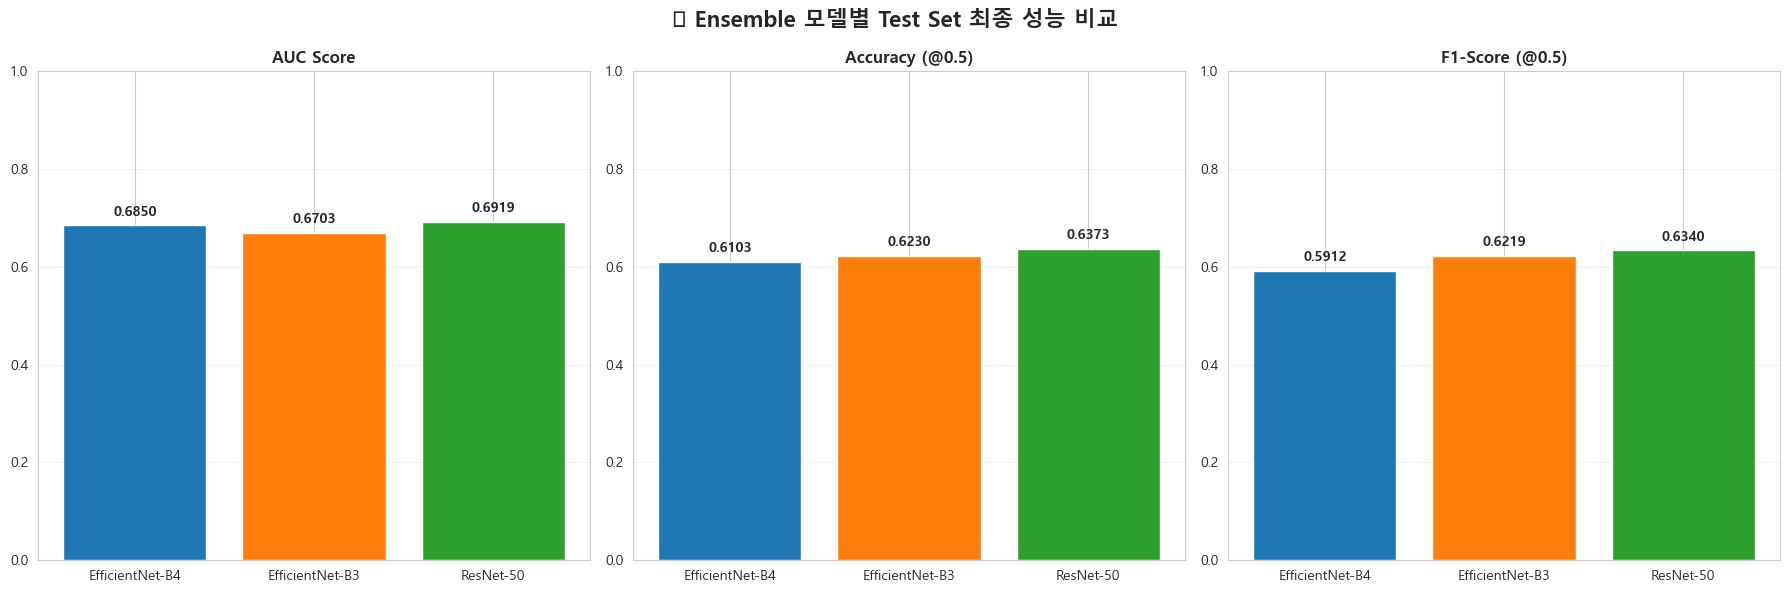

✅ 최종 성능 비교 그래프 생성 완료


In [31]:
print("="*80)
print("📊 Ensemble 모델 학습 히스토리 시각화")
print("="*80)

# 개별 모델 최종 성능 비교 그래프 (학습 history 대신)
try:
    if 'individual_results' in dir():
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle('📊 Ensemble 모델별 Test Set 최종 성능 비교', fontsize=16, fontweight='bold')
        
        model_names = list(individual_results.keys())
        
        # AUC 비교
        aucs = [individual_results[name]['AUC'] for name in model_names]
        axes[0].bar(model_names, aucs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        axes[0].set_title('AUC Score', fontsize=12, fontweight='bold')
        axes[0].set_ylim(0, 1)
        axes[0].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(aucs):
            axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        # Accuracy 비교
        accs = [individual_results[name]['Acc@0.5'] for name in model_names]
        axes[1].bar(model_names, accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        axes[1].set_title('Accuracy (@0.5)', fontsize=12, fontweight='bold')
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(accs):
            axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        # F1 비교
        f1s = [individual_results[name]['F1@0.5'] for name in model_names]
        axes[2].bar(model_names, f1s, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        axes[2].set_title('F1-Score (@0.5)', fontsize=12, fontweight='bold')
        axes[2].set_ylim(0, 1)
        axes[2].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(f1s):
            axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        print("✅ 최종 성능 비교 그래프 생성 완료")
    else:
        print("⚠️ 개별 모델 결과(individual_results)가 없습니다.")
        print("   먼저 'Threshold 최적화' 셀을 실행하세요.")
        
except Exception as e:
    print(f"⚠️ 그래프 생성 중 오류: {e}")
    print("\n💡 해결 방법:")
    print("   1. 'Threshold 최적화' 섹션을 먼저 실행하세요")
    print("   2. individual_results 변수가 생성되어야 합니다")

🎯 Confusion Matrix 생성 (개별 모델 + 앙상블)

📊 EfficientNet-B4 평가 중...


                                                                    c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()



📊 EfficientNet-B3 평가 중...


c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()



📊 ResNet-50 평가 중...


c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\3181936776.py:65: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\THKIM\anaconda3\envs\df_gpu\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\THKIM\AppData\Local\Temp\ipykernel_20288\318193

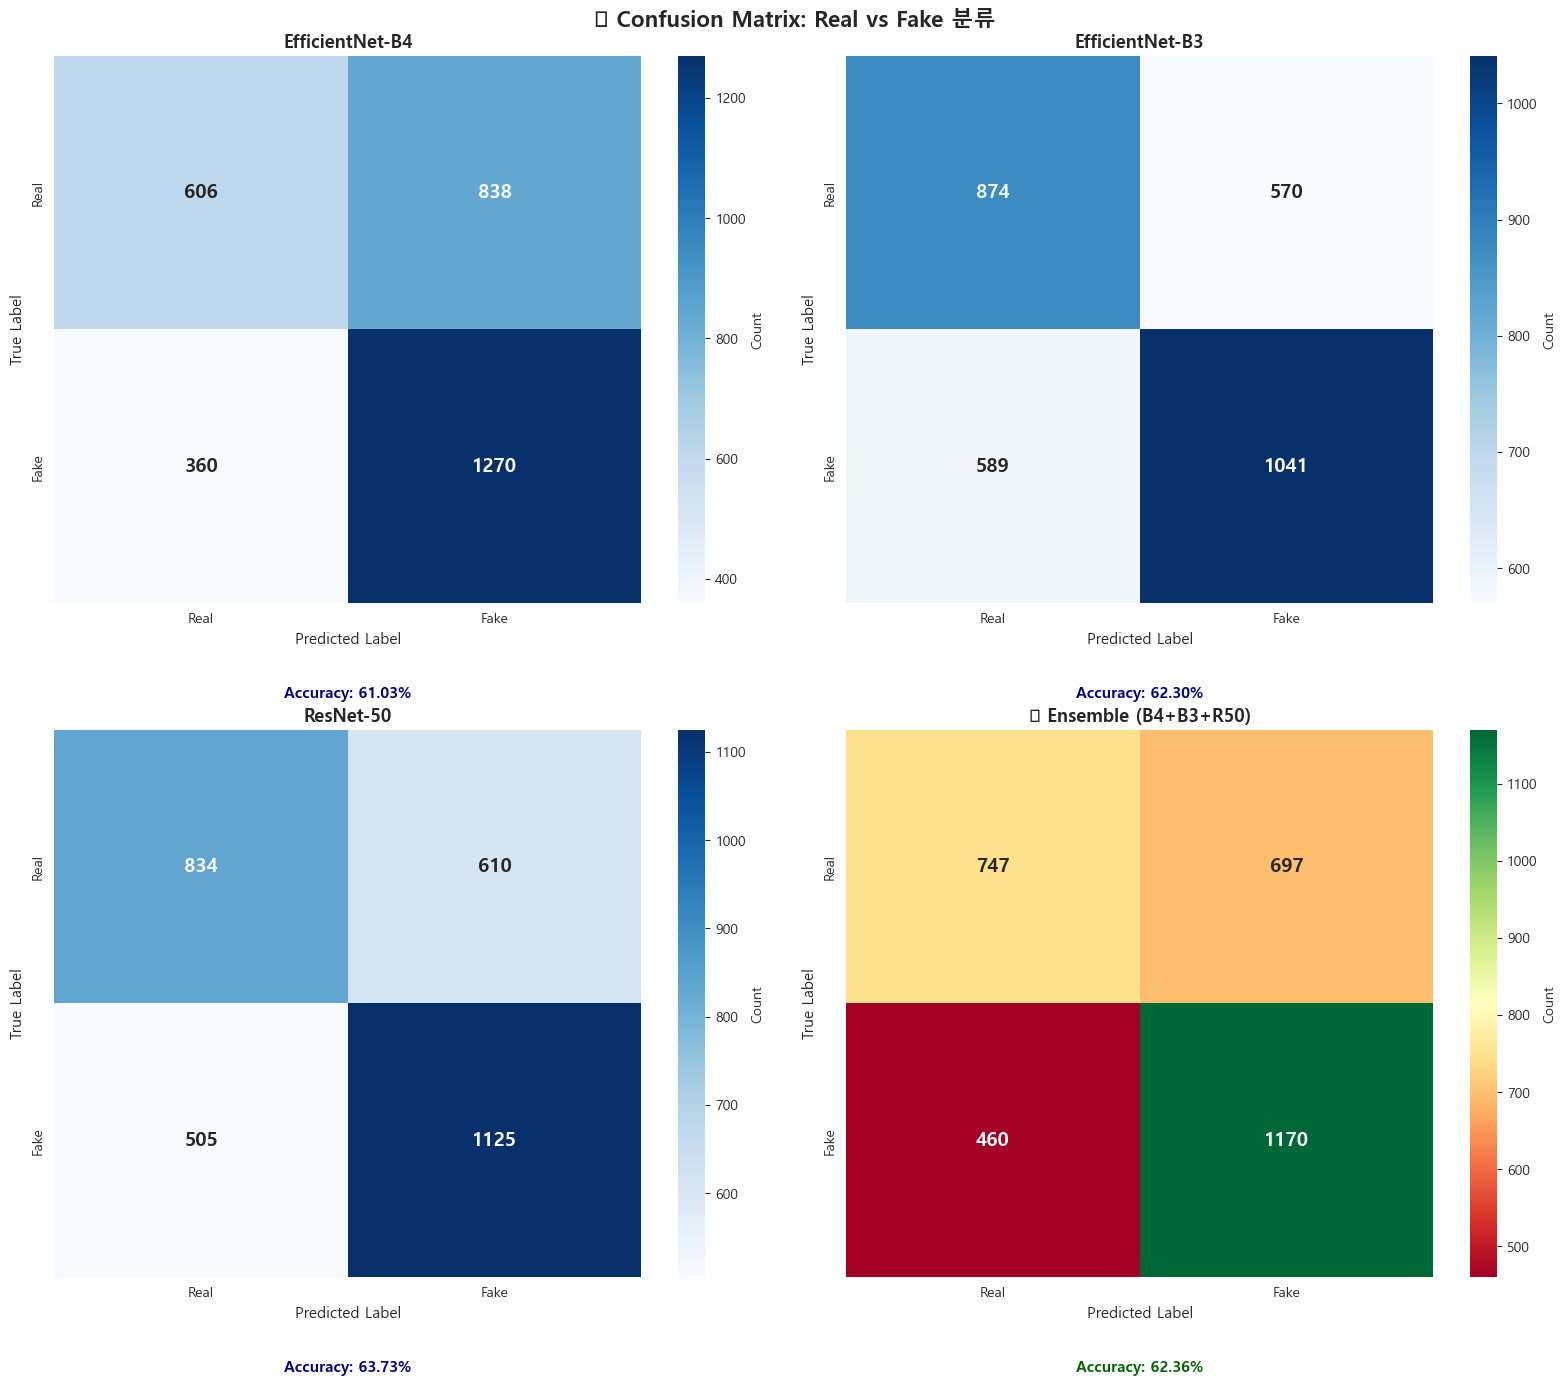


✅ Confusion Matrix 생성 완료


In [32]:
print("="*80)
print("🎯 Confusion Matrix 생성 (개별 모델 + 앙상블)")
print("="*80)

# 1. 개별 모델 Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('🔍 Confusion Matrix: Real vs Fake 분류', fontsize=16, fontweight='bold')

# 개별 모델 평가
for idx, (name, model) in enumerate(models_ensemble):
    print(f"\n📊 {name} 평가 중...")
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader_ensemble, desc=f'  {name}', leave=False):
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # 히트맵 그리기
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Fake'], 
                yticklabels=['Real', 'Fake'],
                cbar_kws={'label': 'Count'},
                ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    
    # 정확도 표시
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    ax.text(0.5, -0.15, f'Accuracy: {accuracy:.2%}', 
            ha='center', va='top', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='darkblue')

# 4번째 subplot에 앙상블 결과
ax_ens = axes[1, 1]
ensemble_preds = (all_test_probs_ensemble > 0.5).astype(int)
cm_ens = confusion_matrix(all_test_labels_ensemble, ensemble_preds)

sns.heatmap(cm_ens, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'],
            cbar_kws={'label': 'Count'},
            ax=ax_ens, annot_kws={'size': 14, 'weight': 'bold'})

ax_ens.set_title('🏆 Ensemble (B4+B3+R50)', fontsize=13, fontweight='bold')
ax_ens.set_xlabel('Predicted Label', fontsize=11)
ax_ens.set_ylabel('True Label', fontsize=11)

accuracy_ens = (cm_ens[0, 0] + cm_ens[1, 1]) / cm_ens.sum()
ax_ens.text(0.5, -0.15, f'Accuracy: {accuracy_ens:.2%}', 
            ha='center', va='top', transform=ax_ens.transAxes,
            fontsize=11, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

print("\n✅ Confusion Matrix 생성 완료")

In [ ]:
print("="*80)
print("🖼️ 예측 결과 샘플 시각화 (정답 vs 오답)")
print("="*80)

# 앙상블 모델로 전체 테스트셋 예측
ensemble_preds_final = (all_test_probs_ensemble > 0.5).astype(int)

# 정답/오답 인덱스 찾기
correct_indices = np.where(all_test_labels_ensemble == ensemble_preds_final)[0]
incorrect_indices = np.where(all_test_labels_ensemble != ensemble_preds_final)[0]

# Real 정답, Real 오답, Fake 정답, Fake 오답 각각 찾기
correct_real = [i for i in correct_indices if all_test_labels_ensemble[i] == 0]
correct_fake = [i for i in correct_indices if all_test_labels_ensemble[i] == 1]
incorrect_real = [i for i in incorrect_indices if all_test_labels_ensemble[i] == 0]
incorrect_fake = [i for i in incorrect_indices if all_test_labels_ensemble[i] == 1]

print(f"\n📊 분류 결과:")
print(f"   ✅ Real 정답: {len(correct_real):,}개")
print(f"   ✅ Fake 정답: {len(correct_fake):,}개")
print(f"   ❌ Real 오답 (Fake로 예측): {len(incorrect_real):,}개")
print(f"   ❌ Fake 오답 (Real로 예측): {len(incorrect_fake):,}개")

# 샘플 이미지 선택 (각 카테고리에서 6개씩)
num_samples = 6

def safe_sample(indices, n):
    if len(indices) == 0:
        return []
    return np.random.choice(indices, min(n, len(indices)), replace=False)

samples_correct_real = safe_sample(correct_real, num_samples)
samples_correct_fake = safe_sample(correct_fake, num_samples)
samples_incorrect_real = safe_sample(incorrect_real, num_samples)
samples_incorrect_fake = safe_sample(incorrect_fake, num_samples)

# 시각화 함수
def visualize_predictions(sample_indices, labels, preds, probs, title, color):
    """예측 결과를 시각화하는 함수"""
    if len(sample_indices) == 0:
        print(f"   ⚠️ {title}: 샘플 없음")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold', color=color)
    
    for idx, sample_idx in enumerate(sample_indices):
        if idx >= 6:
            break
        
        ax = axes[idx // 3, idx % 3]
        
        # 이미지 로드
        img_path = test_df.iloc[sample_idx]['path']
        img = Image.open(img_path).convert('RGB')
        
        # 이미지 표시
        ax.imshow(img)
        ax.axis('off')
        
        # 라벨 정보
        true_label = "Real" if labels[sample_idx] == 0 else "Fake"
        pred_label = "Real" if preds[sample_idx] == 0 else "Fake"
        confidence = probs[sample_idx] if preds[sample_idx] == 1 else (1 - probs[sample_idx])
        
        # 제목 설정
        title_text = f"True: {true_label} | Pred: {pred_label}\n신뢰도: {confidence:.2%}"
        ax.set_title(title_text, fontsize=10, fontweight='bold', 
                    color='green' if labels[sample_idx] == preds[sample_idx] else 'red')
    
    # 빈 subplot 제거
    for idx in range(len(sample_indices), 6):
        axes[idx // 3, idx % 3].axis('off')
    
    plt.tight_layout()
    plt.show()

# 1. Real 정답 샘플
print("\n" + "="*80)
print("✅ Real 이미지 정답 샘플")
visualize_predictions(samples_correct_real, all_test_labels_ensemble, 
                     ensemble_preds_final, all_test_probs_ensemble,
                     "✅ Real 이미지를 Real로 정확히 분류한 샘플", 'darkgreen')

# 2. Fake 정답 샘플
print("\n" + "="*80)
print("✅ Fake 이미지 정답 샘플")
visualize_predictions(samples_correct_fake, all_test_labels_ensemble, 
                     ensemble_preds_final, all_test_probs_ensemble,
                     "✅ Fake 이미지를 Fake로 정확히 분류한 샘플", 'darkgreen')

# 3. Real 오답 샘플 (FP: False Positive)
print("\n" + "="*80)
print("❌ Real → Fake 오분류 샘플 (False Positive)")
visualize_predictions(samples_incorrect_real, all_test_labels_ensemble, 
                     ensemble_preds_final, all_test_probs_ensemble,
                     "❌ Real 이미지를 Fake로 잘못 분류한 샘플 (False Positive)", 'darkred')

# 4. Fake 오답 샘플 (FN: False Negative)
print("\n" + "="*80)
print("❌ Fake → Real 오분류 샘플 (False Negative)")
visualize_predictions(samples_incorrect_fake, all_test_labels_ensemble, 
                     ensemble_preds_final, all_test_probs_ensemble,
                     "❌ Fake 이미지를 Real로 잘못 분류한 샘플 (False Negative)", 'darkred')

print("\n" + "="*80)
print("✅ 예측 결과 시각화 완료")
print("="*80)